# 📊 Étape 4 : Analyse Exploratoire des Données (EDA) Croisée

Fusion des données textuelles (Sentiment **FinBERT**) et des données financières, puis **analyse exploratoire complète**.

### 📋 Plan (structure du mémoire) :
1. **Étude statistique** : moyenne, variance, corrélation
2. **Visualisation** : évolution des prix vs sentiment
3. **Analyse des relations** :
   - Corrélation sentiment – rendement
   - Détection de décalages temporels (**lag effect**)


## 📦 Importation


In [107]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
print(" Imports OK")


 Imports OK


## 📥 Chargement des données


In [108]:
FINANCE_PATH = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\FINANCE_2023_2026_Well_Prepared.csv"
df_finance = pd.read_csv(FINANCE_PATH, parse_dates=['Date'])

print(f"Shape finance: {df_finance.shape}")
print(f"Période: {df_finance['Date'].min()} → {df_finance['Date'].max()}")
print(f"Tickers: {sorted(df_finance['Ticker'].unique())}")
print(f"Colonnes: {list(df_finance.columns)}")
df_finance.head()


Shape finance: (8244, 6)
Période: 2023-01-03 00:00:00 → 2026-08-27 00:00:00
Tickers: ['AAPL', 'AMZN', 'BRK-B', 'GOOGL', 'JPM', 'META', 'MSFT', 'TSLA', 'UNH']
Colonnes: ['Date', 'Ticker', 'Volume', 'StockChange', 'Target', 'Daily_Volatility']


,Date,Ticker,Volume,StockChange,Target,Daily_Volatility
0,2023-01-03,AAPL,112117500,-0.039991,0,0.051658
1,2023-01-04,AAPL,89113600,-0.004177,0,0.028213
2,2023-01-05,AAPL,80962700,-0.016597,0,0.023677
3,2023-01-06,AAPL,87754700,0.028648,1,0.042854
4,2023-01-09,AAPL,70790800,-0.002453,0,0.026979


In [109]:
SENTIMENT_PATH = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\data_2023_2026_INDICATEURS.csv"
df_sentiment = pd.read_csv(SENTIMENT_PATH, parse_dates=['Date'])

print(f"Shape sentiment: {df_sentiment.shape}")
print(f"Période: {df_sentiment['Date'].min()} → {df_sentiment['Date'].max()}")
print(f"Colonnes: {list(df_sentiment.columns)}")
df_sentiment.head()


Shape sentiment: (4909, 9)
Période: 2023-01-01 00:00:00 → 2026-07-12 00:00:00
Colonnes: ['Date', 'Ticker', 'FinBERT_Positive', 'FinBERT_Negative', 'FinBERT_Neutral', 'Volume_Messages', 'Score_Net', 'Bullishness_Index', 'Polarite_Index']


,Date,Ticker,FinBERT_Positive,FinBERT_Negative,FinBERT_Neutral,Volume_Messages,Score_Net,Bullishness_Index,Polarite_Index
0,2023-01-01,BRK-B,0.9986,0.0000,0.0014,1,0.9986,1.0000,0.9986
1,2023-01-01,META,0.9999,0.0000,0.0000,1,0.9999,1.0000,1.0000
2,2023-01-02,AAPL,0.0019,0.0002,0.9979,1,0.0017,0.9052,0.0021
3,2023-01-02,BRK-B,0.0019,0.0002,0.9979,1,0.0017,0.9052,0.0021
4,2023-01-02,TSLA,0.0000,1.0000,0.0000,1,-1.0000,0.0000,1.0000


## 🔗 Fusion (Inner Join sur Date + Ticker)


In [110]:
df_finance = df_finance.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df_sentiment = df_sentiment.sort_values(['Ticker', 'Date']).reset_index(drop=True)

df_master = pd.merge(df_finance, df_sentiment, on=['Date', 'Ticker'], how='inner')
df_master = df_master.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f" Fusion réussie: {df_master.shape[0]} lignes")
print(f"Période: {df_master['Date'].min()} → {df_master['Date'].max()}")
print(f"Tickers: {sorted(df_master['Ticker'].unique())}")
print(f"\nNaN par colonne:")
print(df_master.isnull().sum())


 Fusion réussie: 3798 lignes
Période: 2023-01-03 00:00:00 → 2026-07-10 00:00:00
Tickers: ['AAPL', 'AMZN', 'BRK-B', 'GOOGL', 'JPM', 'META', 'MSFT', 'TSLA', 'UNH']

NaN par colonne:
Date                 0
Ticker               0
Volume               0
StockChange          0
Target               0
Daily_Volatility     0
FinBERT_Positive     0
FinBERT_Negative     0
FinBERT_Neutral      0
Volume_Messages      0
Score_Net            0
Bullishness_Index    0
Polarite_Index       0
dtype: int64


il n ya pas des valeurs manquantes 

## 1️⃣ Étude statistique : moyenne, variance, corrélation


In [111]:
# Statistiques descriptives des variables financières
print("=== Variables financières — globales ===")
print(df_finance[['Volume', 'StockChange', 'Daily_Volatility']].describe().T)

print("\n=== Par ticker : Moyenne (μ), Variance (σ²), écart-type du rendement intraday ===")
stat_ret = df_finance.groupby('Ticker')['StockChange'].agg(['mean', 'var', 'std', 'skew', 'count'])
print(stat_ret)

print("\n=== Par ticker : Volume moyen et volatilité moyenne ===")
print(df_finance.groupby('Ticker')[['Volume', 'Daily_Volatility']].mean())


=== Variables financières — globales ===
                   count          mean           std           min  \
Volume            8244.0  3.330643e+07  3.493540e+07  1.135000e+06   
StockChange       8244.0  6.771617e-04  1.635374e-02 -1.203374e-01   
Daily_Volatility  8244.0  2.325412e-02  1.429270e-02  4.437969e-03   

                           25%           50%           75%           max  
Volume            8.316900e+06  2.274640e+07  4.520620e+07  3.186799e+08  
StockChange      -7.725763e-03  6.834534e-04  9.034564e-03  2.114469e-01  
Daily_Volatility  1.411996e-02  1.950197e-02  2.806820e-02  2.261338e-01  

=== Par ticker : Moyenne (μ), Variance (σ²), écart-type du rendement intraday ===
            mean       var       std      skew  count
Ticker                                               
AAPL    0.001345  0.000193  0.013879  1.476963    916
AMZN    0.000422  0.000245  0.015645  0.423524    916
BRK-B   0.000043  0.000078  0.008860  0.161303    916
GOOGL   0.001293  0.00022

# Rapport d'analyse statistique et financière des actifs

## 1. Vue d'ensemble globale (8 244 observations)

* **Rendement journalier (`StockChange`)** :
  * **Moyenne ($\mu$)** : $+0{,}068\,\%$ par séance (`6,77e-04`)
  * **Médiane** : $+0{,}068\,\%$
  * **Écart-type ($\sigma$)** : $1{,}64\,\%$ (`0,0164`), soit un niveau de dispersion **24 fois supérieur à la moyenne**.
  * **Extrêmes** : Minimum à $-12{,}03\,\%$ et maximum à $+21{,}14\,\%$.
* **Volatilité intraday (`Daily_Volatility`)** :
  * **Moyenne** : $2{,}33\,\%$ (médiane à $1{,}95\,\%$)
  * **Pic historique** : $22{,}61\,\%$.
* **Volumes de transactions (`Volume`)** :
  * **Moyenne** : $33{,}3\text{ M}$ de titres échangés par jour.
  * **Écart-type** : $34{,}9\text{ M}$, traduisant une forte asymétrie tirée par des journées d'échanges exceptionnelles (maximum à $318{,}7\text{ M}$).

---

## 2. Tableau comparatif Performance vs Risque par Ticker (916 séances)

| Ticker | Rendement Moyen ($\mu$) | Variance ($\sigma^2$) | Écart-type ($\sigma$) | Volatilité moy. | Profil de risque |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **TSLA** | $+0{,}111\,\%$ | $0{,}000827$ | **$2{,}88\,\%$** | **$4{,}24\,\%$** | **Spéculatif / Très forte dispersion** |
| **META** | $+0{,}060\,\%$ | $0{,}000309$ | $1{,}76\,\%$ | $2{,}67\,\%$ | Volatilité élevée |
| **AMZN** | $+0{,}042\,\%$ | $0{,}000245$ | $1{,}56\,\%$ | $2{,}39\,\%$ | Risque modéré à élevé |
| **GOOGL**| **$+0{,}129\,\%$** | $0{,}000226$ | $1{,}51\,\%$ | $2{,}31\,\%$ | Performance solide / Risque intermédiaire |
| **AAPL** | **$+0{,}135\,\%$** | $0{,}000193$ | $1{,}39\,\%$ | $1{,}97\,\%$ | **Meilleur ratio Rendement / Risque** |
| **MSFT** | $+0{,}037\,\%$ | $0{,}000163$ | $1{,}28\,\%$ | $1{,}90\,\%$ | Profil défensif au sein de la Tech |
| **JPM**  | $+0{,}088\,\%$ | $0{,}000155$ | $1{,}24\,\%$ | $1{,}84\,\%$ | Valeur financière équilibrée |
| **UNH**  | $+0{,}003\,\%$ | $0{,}000212$ | $1{,}46\,\%$ | $2{,}24\,\%$ | Faible rendement sur la période |
| **BRK-B**| $+0{,}004\,\%$ | $0{,}000078$ | **$0{,}89\,\%$** | **$1{,}37\,\%$** | **Actif Refuge (Stabilité maximale)** |

---

## 3. Principaux enseignements statistiques

1. **Hiérarchie du risque via l'écart-type (`std`)** :
   * **TSLA** est l'actif le plus risqué et imprévisible de l'échantillon avec un écart-type de **$2{,}88\,\%$**, soit plus de **3 fois** celui de **BRK-B** ($0{,}89\,\%$).
   * **AAPL** optimise le couple rendement/risque avec le rendement moyen le plus élevé ($+0{,}135\,\%$) pour une variabilité maîtrisée ($1{,}39\,\%$).
2. **Asymétrie des distributions (`Skewness`)** :
   * **AAPL (`skew = +1{,}48`)** : Très forte asymétrie positive, caractérisée par des hausses extrêmes marquées.
   * **UNH (`skew = -0{,}33`)** : Seul actif affichant une asymétrie négative, indiquant des décrochages baissiers plus violents que ses phases haussières.
3. **Liquidité** :
   * Forte concentration des volumes sur **TSLA** ($99{,}8\text{ M}$ titres/jour), **AAPL** ($55{,}7\text{ M}$) et **AMZN** ($48{,}2\text{ M}$).

---

## 4. Recommandations pour la modélisation (ex. Régression Logistique)

* **Standardisation obligatoire (`StandardScaler`)** : Les variables ont des ordres de grandeur hétérogènes (`Volume` en $10^7$ vs `StockChange` et `Daily_Volatility` en $10^{-2}$). Il est indispensable de centrer-réduire (soustraire la moyenne et diviser par l'écart-type) pour assurer la convergence de la descente de gradient et obtenir des coefficients interprétables.
* **Gestion des valeurs extrêmes** : La forte dispersion de TSLA et les pics de volatilité suggèrent d'évaluer la robustesse du modèle face aux événements de queue de distribution.

In [115]:
# Statistiques descriptives des variables de sentiment
print("=== Variables sentiment — globales ===")
print(df_sentiment[['Score_Net', 'Polarite_Index', 'Bullishness_Index', 'Volume_Messages']].describe().T)

print("\n=== Par ticker : Moyenne (μ), Variance (σ²) du Score_Net ===")
print(df_sentiment.groupby('Ticker')['Score_Net'].agg(['mean', 'var', 'std', 'skew', 'count']))

print("\n=== Par ticker : Volume de messages moyen (activité Reddit) ===")
print(df_sentiment.groupby('Ticker')['Volume_Messages'].mean())


=== Variables sentiment — globales ===
                    count      mean        std  min     25%     50%     75%  \
Score_Net          4909.0  0.178060   0.473583 -1.0 -0.0003  0.0267  0.4876   
Polarite_Index     4909.0  0.449906   0.374083  0.0  0.0046  0.4977  0.7448   
Bullishness_Index  4909.0  0.579117   0.398192  0.0  0.1126  0.6681  0.9967   
Volume_Messages    4909.0  6.734365  16.175494  1.0  1.0000  2.0000  4.0000   

                     max  
Score_Net            1.0  
Polarite_Index       1.0  
Bullishness_Index    1.0  
Volume_Messages    226.0  

=== Par ticker : Moyenne (μ), Variance (σ²) du Score_Net ===
            mean       var       std      skew  count
Ticker                                               
AAPL    0.157125  0.241800  0.491732 -0.240194    527
AMZN    0.195185  0.217143  0.465986 -0.048537    690
BRK-B   0.153543  0.140189  0.374418  0.342592    613
GOOGL   0.215719  0.239486  0.489373 -0.191085    537
JPM     0.191881  0.221123  0.470237 -0.2235

# Rapport d'analyse du sentiment social (Reddit)

## 1. Vue d'ensemble globale (4 909 observations)

* **Score Net (`Score_Net`)** :
  * **Moyenne ($\mu$)** : $+0{,}178$ (sur une échelle de $-1$ à $+1$).
  * **Médiane** : $+0{,}027$ avec un premier quartile légèrement négatif ($-0{,}0003$).
  * **Écart-type ($\sigma$)** : $0{,}474$, traduisant une forte dispersion et une alternance fréquente entre optimisme et pessimisme.
* **Indice d'optimisme (`Bullishness_Index`)** :
  * **Moyenne** : $0{,}579$ (médiane à $0{,}668$, 75e percentile à $0{,}997$), confirmant un biais haussier naturel au sein des communautés de discussion.
* **Volume d'activité sociale (`Volume_Messages`)** :
  * **Médiane** : $2\text{ messages}$ par jour (75 % des séances ont $\le 4\text{ messages}$).
  * **Moyenne** : $6{,}73\text{ messages}$ (écart-type à $16{,}18$).
  * **Pic historique** : $226\text{ messages}$, illustrant la présence d'épisodes viraux ponctuels lors d'annonces majeures.

---

## 2. Tableau comparatif du sentiment par Ticker

| Ticker | Score Net Moyen ($\mu$) | Variance ($\sigma^2$) | Écart-type ($\sigma$) | Asymétrie (*Skew*) | Volume Reddit moy. | Profil de sentiment |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **MSFT** | **$+0{,}251$** | $0{,}243$ | $0{,}493$ | $-0{,}19$ | **$7{,}70$** | **Sentiment le plus haussier et actif** |
| **GOOGL**| $+0{,}216$ | $0{,}239$ | $0{,}489$ | $-0{,}19$ | $7{,}55$ | Fort optimisme régulier |
| **META** | $+0{,}201$ | $0{,}223$ | $0{,}472$ | $-0{,}14$ | $7{,}37$ | Sentiment positif soutenu |
| **AMZN** | $+0{,}195$ | $0{,}217$ | $0{,}466$ | $-0{,}05$ | $6{,}29$ | Positif et équilibré |
| **JPM**  | $+0{,}192$ | $0{,}221$ | $0{,}470$ | $-0{,}22$ | $6{,}98$ | Optimisme modéré et constant |
| **UNH**  | $+0{,}166$ | $0{,}238$ | $0{,}488$ | $-0{,}32$ | $6{,}78$ | Sentiment positif mais asymétrie baissière |
| **AAPL** | $+0{,}157$ | $0{,}242$ | $0{,}492$ | $-0{,}24$ | $7{,}31$ | Modérément optimiste |
| **BRK-B**| $+0{,}154$ | **$0{,}140$** | **$0{,}374$** | **$+0{,}34$** | **$3{,}62$** | **Consensus stable / Faible bruit social** |
| **TSLA** | **$+0{,}065$** | **$0{,}256$** | **$0{,}506$** | $-0{,}21$ | $7{,}66$ | **Hyper-polarisé / Forte divergence d'avis** |

---

## 3. Enseignements clés

1. **Le cas particulier de TSLA (forte activité, faible adhésion)** :
   * TSLA enregistre le deuxième plus fort volume moyen d'échanges sociaux ($7{,}66\text{ msg/j}$), mais affiche de loin le `Score_Net` moyen le plus faible ($+0{,}065$, près de 4 fois inférieur à MSFT).
   * Sa variance maximale ($0{,}256$) et son écart-type ($0{,}506$) signalent une forte division entre investisseurs très optimistes et vendeurs à découvert.
2. **Plébiscite pour MSFT et les Big Tech** :
   * Microsoft combine le plus fort volume d'engagement ($7{,}70$) et le score net le plus élevé ($0{,}251$).
3. **Stabilité institutionnelle de BRK-B** :
   * Berkshire Hathaway présente la plus faible dispersion d'opinion ($\sigma = 0{,}374$) et le plus faible volume social ($3{,}62$), reflétant un profil d'investisseurs axé sur le long terme.
4. **Asymétrie négative dominante (*Skewness < 0*)** :
   * À l'exception de BRK-B, tous les actifs présentent une asymétrie négative, indiquant que les réactions face aux mauvaises nouvelles sont proportionnellement plus intenses que l'enthousiasme lors des phases haussières.

---

## 4. Recommandations pour la modélisation (Régression Logistique)

* **Transformation du volume social** : En raison de la longue traîne de `Volume_Messages` (médiane à 2 vs maximum à 226), appliquer une transformation logarithmique ($\ln(1 + \text{Volume\_Messages})$) ou un passage par `StandardScaler` afin d'éviter que les journées virales n'écrasent le signal des journées calmes.
* **Croisement Finance & Sentiment** :
  * Évaluer si les pics de sentiment combinés aux pics de volatilité (`Daily_Volatility`) constituent des variables d'interaction pertinentes pour anticiper la direction du rendement (`StockChange`).
Souhaitez-vous maintenant que l'on assemble les variables financières et de sentiment pour construire le jeu d'entraînement (X, y) et entraîner la régression logistique ?

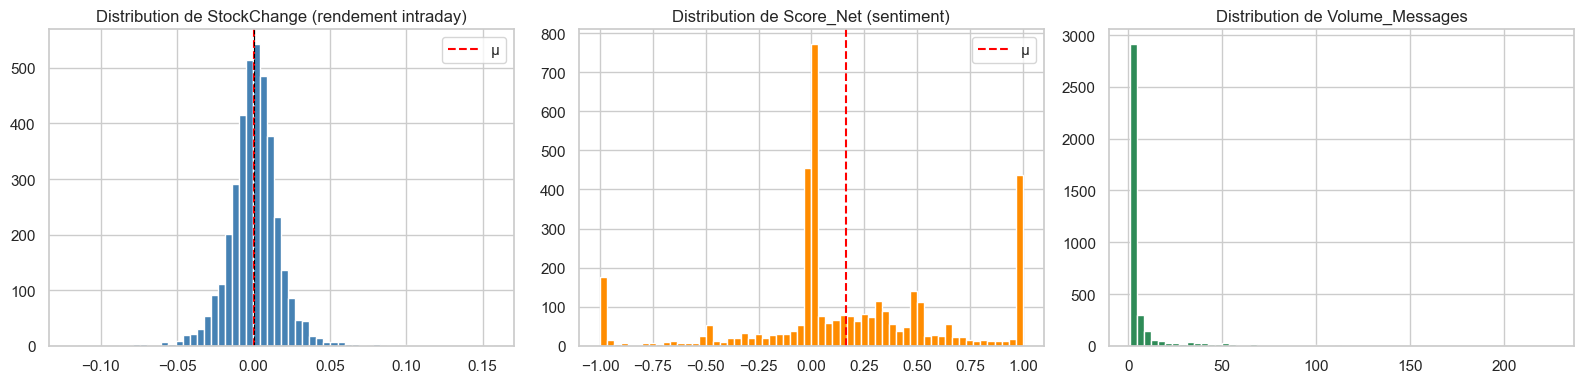

In [117]:
# Distribution des variables clés (répartition autour de la moyenne)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_master['StockChange'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de StockChange (rendement intraday)')
axes[0].axvline(df_master['StockChange'].mean(), color='red', ls='--', label='μ')
axes[0].axvline(0, color='black', ls='--', lw=0.8)
axes[0].legend()

axes[1].hist(df_master['Score_Net'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution de Score_Net (sentiment)')
axes[1].axvline(df_master['Score_Net'].mean(), color='red', ls='--', label='μ')
axes[1].legend()

axes[2].hist(df_master['Volume_Messages'], bins=60, color='seagreen', edgecolor='white')
axes[2].set_title('Distribution de Volume_Messages')

plt.tight_layout()
plt.show()


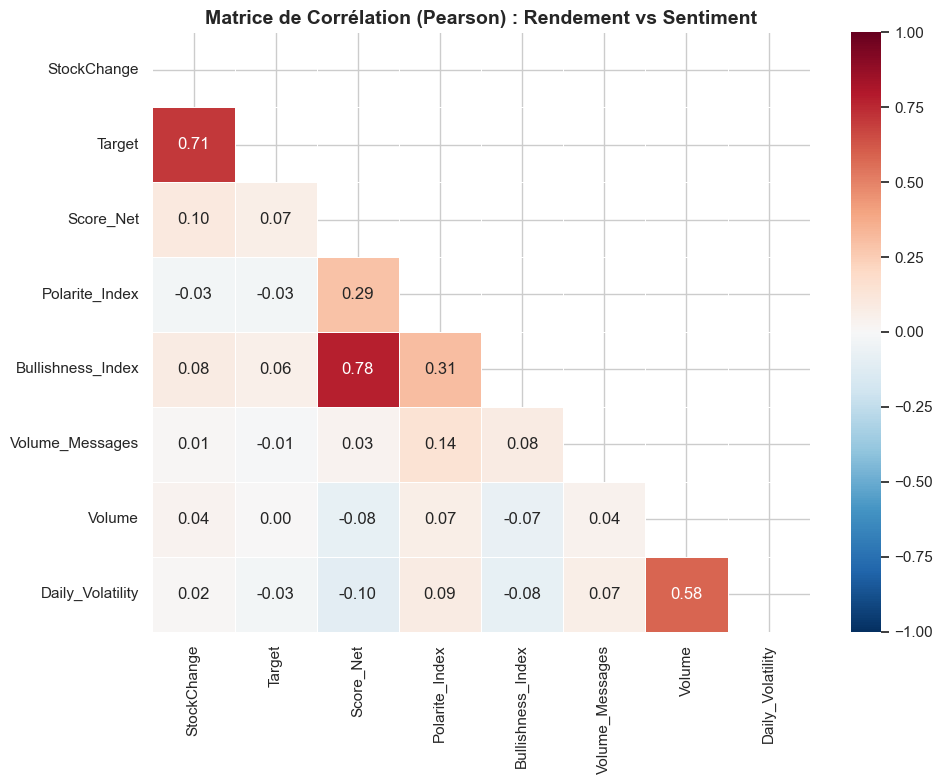


Corrélations avec StockChange (triées par |ρ|):
Target               0.707431
Score_Net            0.097732
Bullishness_Index    0.082689
Volume               0.036890
Polarite_Index      -0.028655
Daily_Volatility     0.015266
Volume_Messages      0.014501


In [118]:
# Matrice de corrélation (Pearson) : sentiment brut vs rendement
corr_cols = ['StockChange', 'Target', 'Score_Net', 'Polarite_Index', 'Bullishness_Index',
             'Volume_Messages', 'Volume', 'Daily_Volatility']
corr_matrix = df_master[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title("Matrice de Corrélation (Pearson) : Rendement vs Sentiment", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Focus sur corrélations avec StockChange
ret_corr = corr_matrix['StockChange'].drop('StockChange').sort_values(key=abs, ascending=False)
print("\nCorrélations avec StockChange (triées par |ρ|):")
print(ret_corr.to_string())


===> on garde tous les variables 

## 2️⃣ Visualisation : évolution des prix vs sentiment


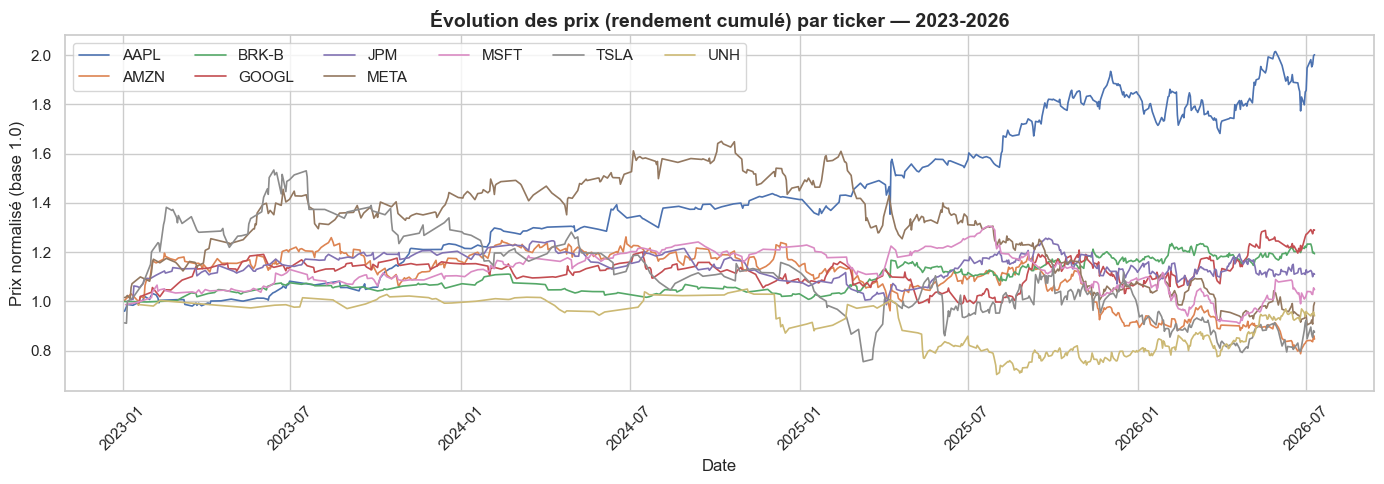

In [119]:
# Évolution des prix : rendement cumulé par ticker (proxy du prix car OHLC supprimées)
fig, ax = plt.subplots(figsize=(14, 5))
for ticker in sorted(df_master['Ticker'].unique()):
    sub = df_master[df_master['Ticker'] == ticker].sort_values('Date')
    cum_ret = (1 + sub['StockChange']).cumprod()
    ax.plot(sub['Date'], cum_ret, label=ticker, linewidth=1.2)

ax.set_title("Évolution des prix (rendement cumulé) par ticker — 2023-2026", fontsize=14, fontweight='bold')
ax.set_ylabel("Prix normalisé (base 1.0)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.legend(ncol=6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


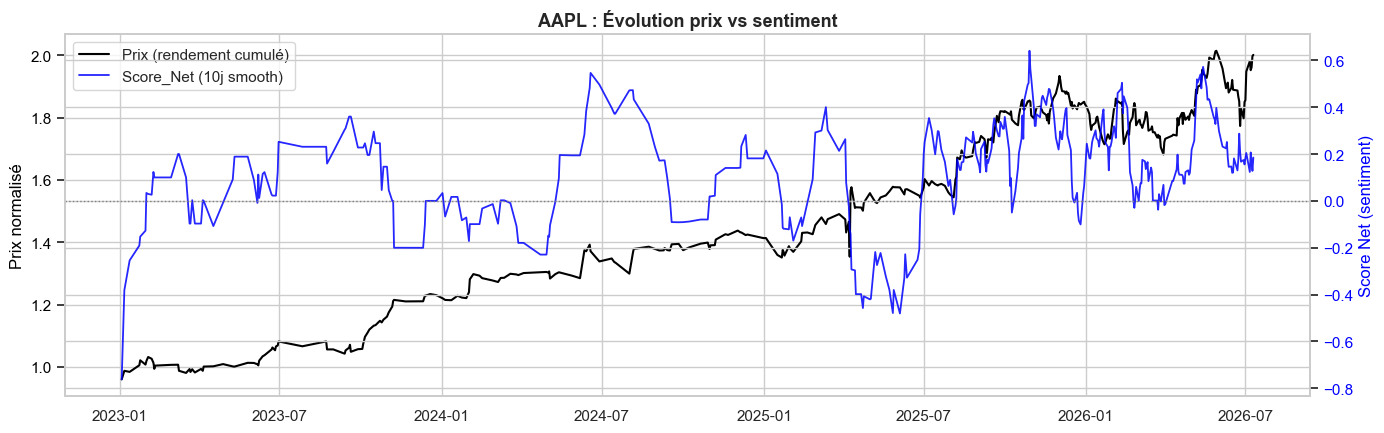

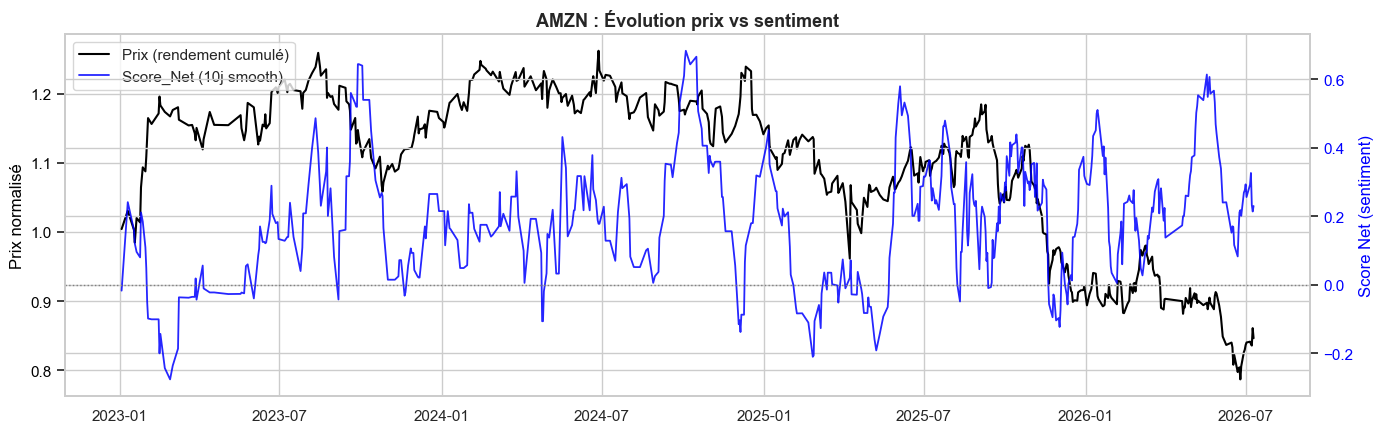

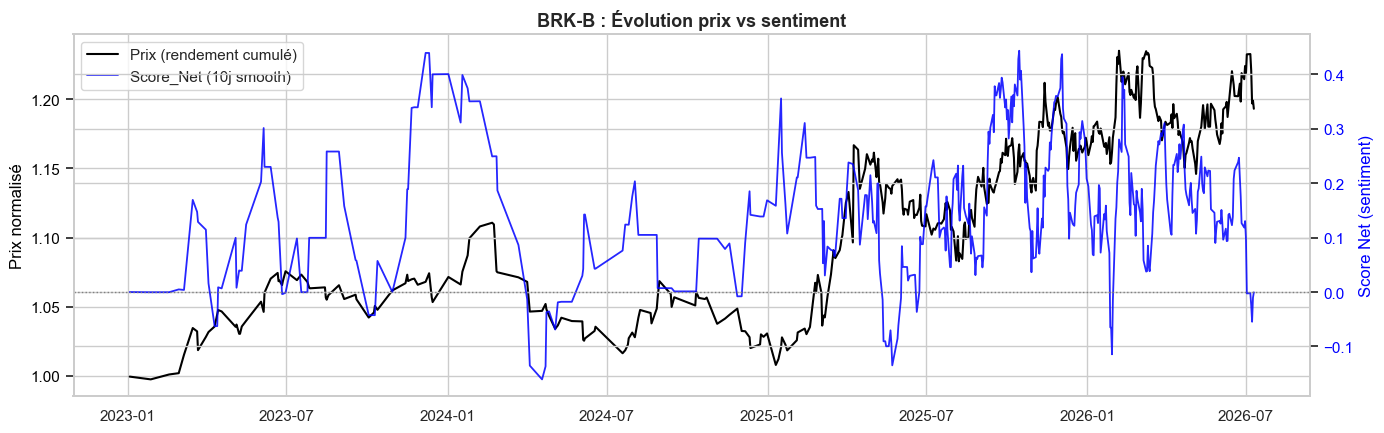

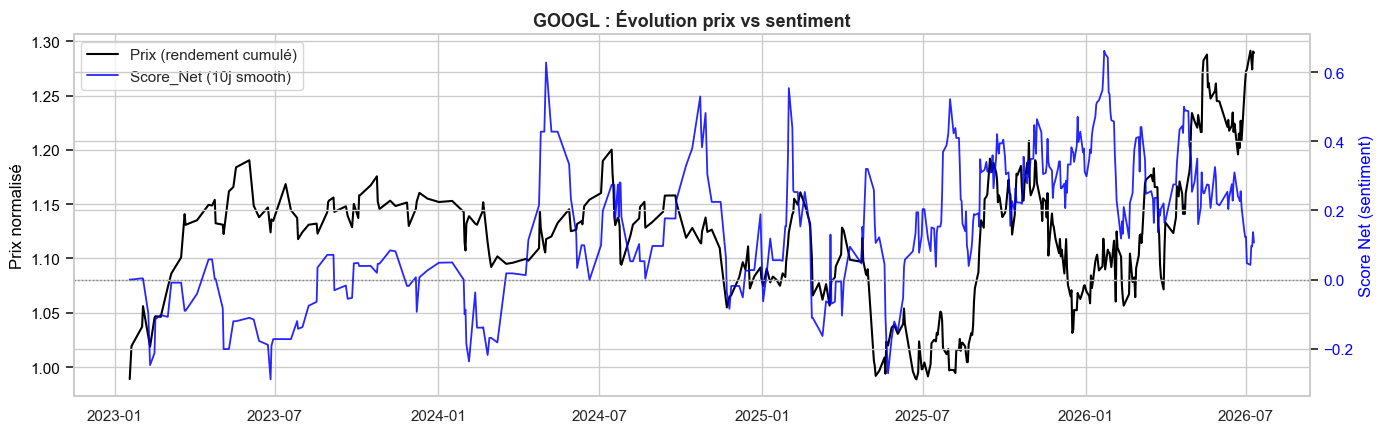

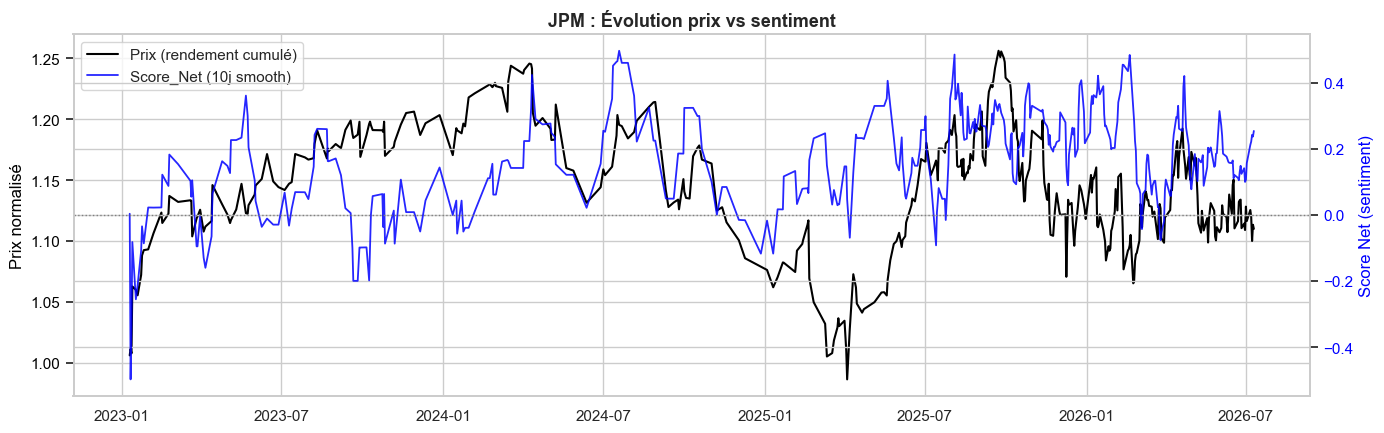

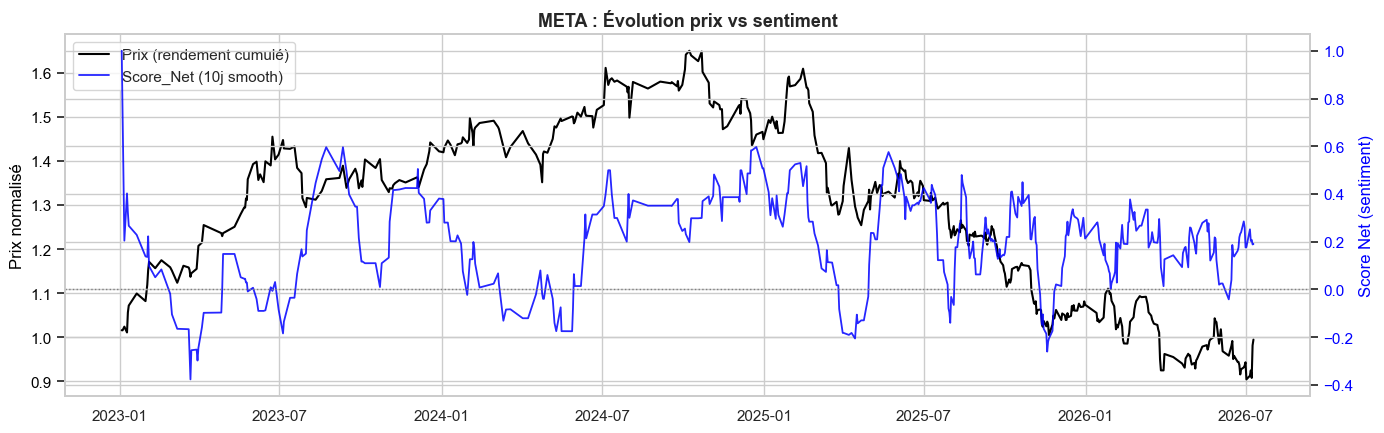

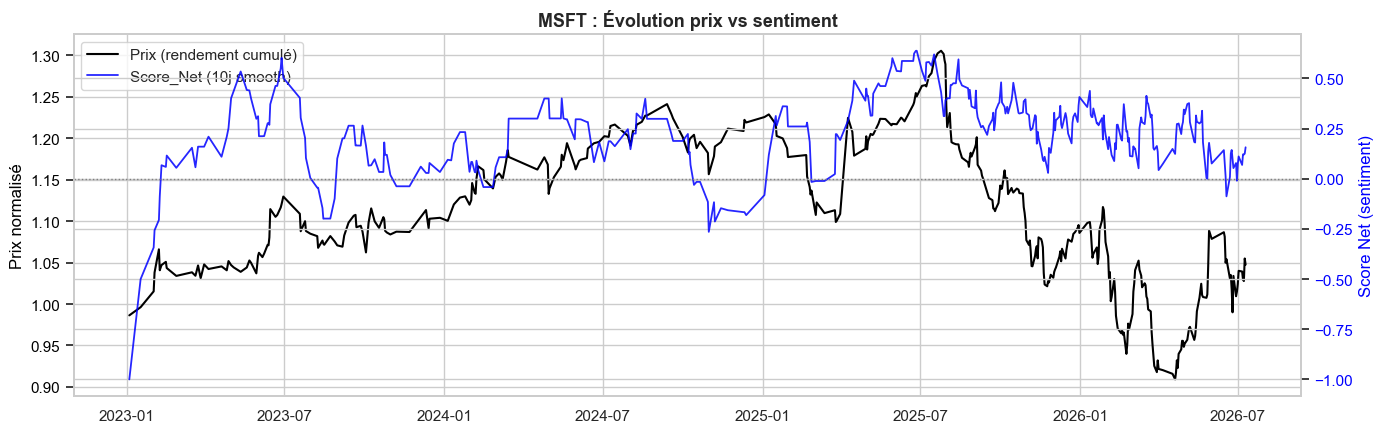

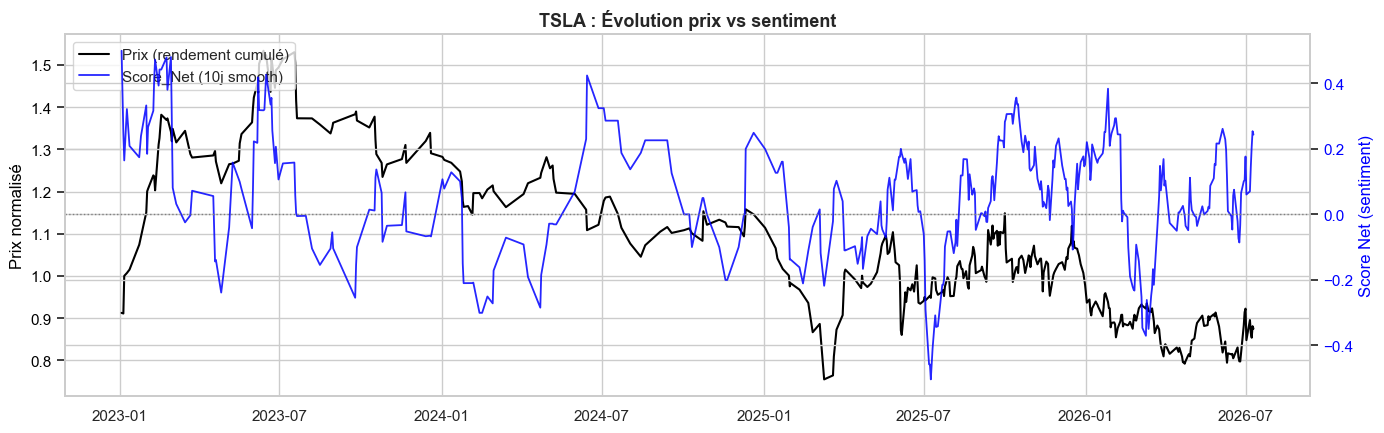

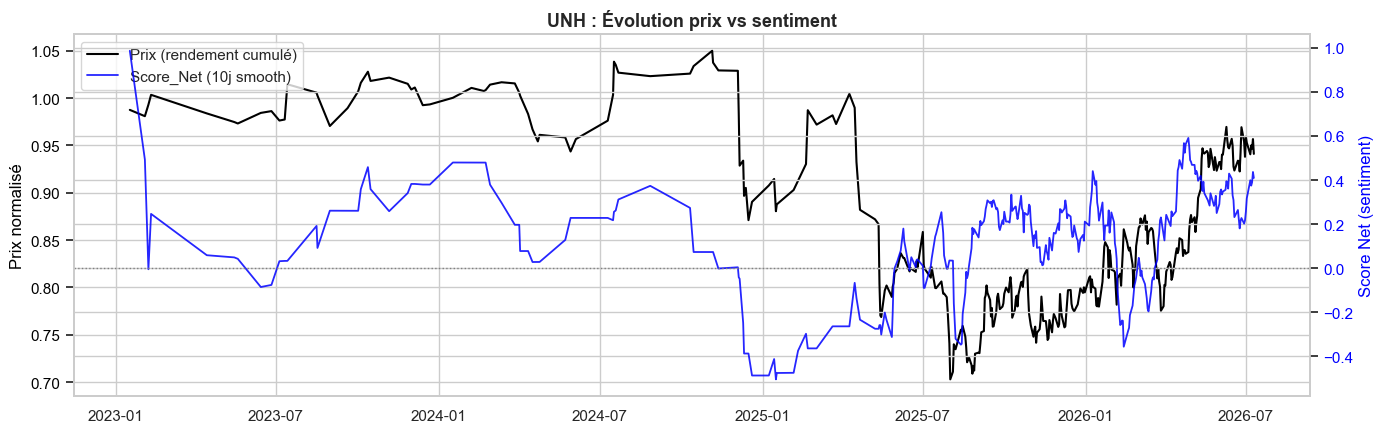

In [120]:
# Évolution des prix vs sentiment : double axe par ticker
tickers = sorted(df_master['Ticker'].unique())

for ticker in tickers:
    df_plot = df_master[df_master['Ticker'] == ticker].sort_values('Date').copy()
    df_plot['Score_Net_Smooth'] = df_plot['Score_Net'].rolling(10, min_periods=1).mean()
    df_plot['Cum_Ret'] = (1 + df_plot['StockChange']).cumprod()

    fig, ax1 = plt.subplots(figsize=(14, 4.5))
    ax1.plot(df_plot['Date'], df_plot['Cum_Ret'], color='black', linewidth=1.5, label='Prix (rendement cumulé)')
    ax1.set_ylabel('Prix normalisé', color='black')
    ax1.tick_params(axis='y', labelcolor='black')

    ax2 = ax1.twinx()
    ax2.plot(df_plot['Date'], df_plot['Score_Net_Smooth'], color='blue', linewidth=1.3, alpha=0.85, label='Score_Net (10j smooth)')
    ax2.axhline(0, color='gray', ls=':', lw=1)
    ax2.set_ylabel('Score Net (sentiment)', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax1.set_title(f"{ticker} : Évolution prix vs sentiment", fontsize=13, fontweight='bold')
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 3️⃣ Analyse des relations


### 3.1 🔗 Corrélation sentiment – rendement


=== Corrélation Score_Net ↔ StockChange ===
Globale : ρ = +0.0977

Par ticker :
        corr_ScoreNet_Rendement  corr_Bullishness_Rendement  \
Ticker                                                        
AAPL                     0.0928                      0.0862   
AMZN                     0.1151                      0.0939   
BRK-B                    0.0837                      0.0648   
GOOGL                    0.1255                      0.1388   
JPM                      0.1049                      0.0821   
META                     0.0078                      0.0556   
MSFT                     0.0907                      0.0773   
TSLA                     0.1418                      0.0622   
UNH                      0.1304                      0.1432   

        corr_Polarite_Rendement    n  
Ticker                                
AAPL                    -0.0058  396  
AMZN                     0.0740  537  
BRK-B                   -0.0019  443  
GOOGL                    0.0336

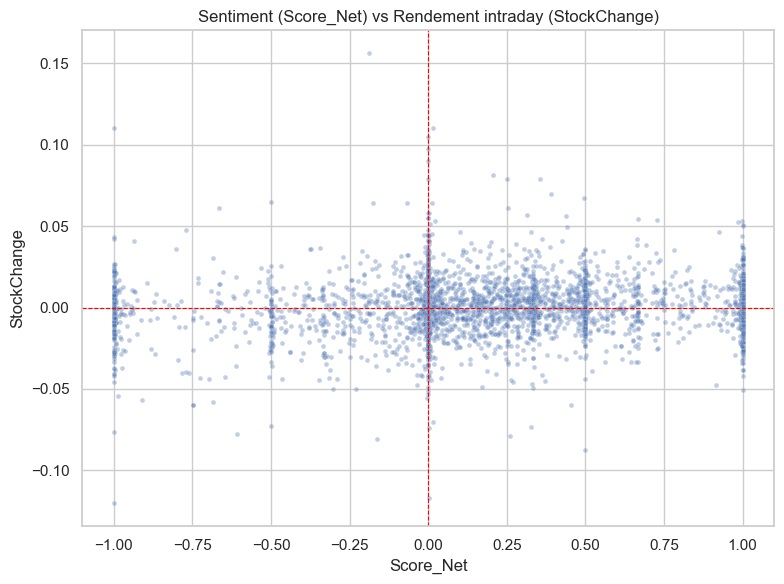

In [123]:
# Corrélation sentiment vs rendement : globale + par ticker
print("=== Corrélation Score_Net ↔ StockChange ===")
print(f"Globale : ρ = {df_master['Score_Net'].corr(df_master['StockChange']):+.4f}")

print("\nPar ticker :")
rows = []
for ticker, g in df_master.groupby('Ticker'):
    rows.append({'Ticker': ticker,
                 'corr_ScoreNet_Rendement': g['Score_Net'].corr(g['StockChange']),
                 'corr_Bullishness_Rendement': g['Bullishness_Index'].corr(g['StockChange']),
                 'corr_Polarite_Rendement': g['Polarite_Index'].corr(g['StockChange']),
                 'n': len(g)})
ticker_corr = pd.DataFrame(rows).set_index('Ticker')
print(ticker_corr.round(4))

# Nuage de points Score_Net vs StockChange (échantillon pour lisibilité)
df_s = df_master.sample(min(5000, len(df_master)), random_state=42)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Score_Net', y='StockChange', data=df_s, alpha=0.35, s=12)
plt.axhline(0, color='red', ls='--', lw=0.8)
plt.axvline(0, color='red', ls='--', lw=0.8)
plt.title("Sentiment (Score_Net) vs Rendement intraday (StockChange)")
plt.tight_layout()
plt.show()


# Analyse de la corrélation Sentiment Reddit vs Rendements financiers

## 1. Vue d'ensemble globale
* **Corrélation globale ($\rho = +0{,}0977$)** : Relation positive, faible mais statistiquement cohérente pour des données boursières à haute fréquence. L'optimisme social s'aligne globalement avec les séances haussières.

## 2. Enseignements par variable
* **`Score_Net` & `Bullishness_Index`** : Corrélations positives sur l'ensemble des 9 tickers (culminant à $+0{,}142$ sur TSLA et $+0{,}143$ sur UNH). Indicateurs directionnels fiables.
* **`Polarite_Index`** : Corrélations négatives sur la majorité des titres (MSFT $-0{,}102$, UNH $-0{,}094$, TSLA $-0{,}088$). Une forte intensité/polarisation émotionnelle est souvent associée à des séances de stress ou de baisse.

## 3. Disparités par actif
* **Sensibilité maximale** : **TSLA** ($\rho = +0{,}142$), **UNH** ($\rho = +0{,}130$) et **GOOGL** ($\rho = +0{,}126$) sont les actifs dont les cours reflètent le plus nettement le sentiment social.
* **Déconnexion** : **META** ($\rho = +0{,}008$) affiche une indépendance quasi-totale entre sentiment brut et variation intraday.

## 4. Implication pour la Régression Logistique
* La combinaison du `Score_Net` (effet positif attendu sur les log-odds) et de la `Polarité` (effet négatif en cas de panique) constitue une base de features complémentaires pour prédire la probabilité de hausse ($P(Y=1)$).

### 3.2 ⏳ Détection des décalages temporels (lag effect)


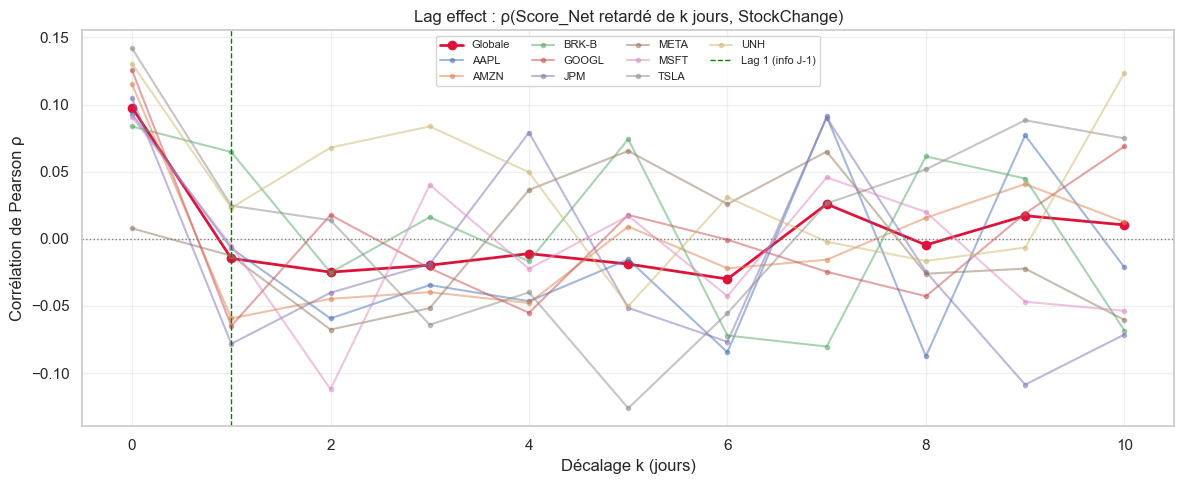


Lag effect global :
 lag  corr_ScoreNet_Rendement
   0                 0.097732
   1                -0.014598
   2                -0.024804
   3                -0.019679
   4                -0.011055
   5                -0.018795
   6                -0.029954
   7                 0.025880
   8                -0.004596
   9                 0.017217
  10                 0.010335

→ Le lag qui maximise |ρ| indique combien de jours de décalage exploitent le sentiment.


In [122]:
# Le sentiment précède-t-il ou suit-il le rendement ?
# On mesure corr(Score_Net retardé de k jours, StockChange) pour k = 0..10
max_lag = 10
lags = range(0, max_lag + 1)

# Lag effect GLOBAL
global_lag = []
for k in lags:
    lagged = df_master.groupby('Ticker')['Score_Net'].shift(k)
    global_lag.append({'lag': k, 'corr_ScoreNet_Rendement': lagged.corr(df_master['StockChange'])})

# Lag effect PAR TICKER
per_ticker = {}
for ticker, g in df_master.groupby('Ticker'):
    per_ticker[ticker] = []
    for k in lags:
        lagged = g['Score_Net'].shift(k)
        per_ticker[ticker].append({'lag': k, 'corr': lagged.corr(g['StockChange'])})

df_lag_global = pd.DataFrame(global_lag)

plt.figure(figsize=(12, 5))
plt.plot(df_lag_global['lag'], df_lag_global['corr_ScoreNet_Rendement'],
         marker='o', color='crimson', linewidth=2, label='Globale')
for ticker, vals in per_ticker.items():
    df_t = pd.DataFrame(vals)
    plt.plot(df_t['lag'], df_t['corr'], marker='.', alpha=0.5, label=ticker)
plt.axhline(0, color='gray', ls=':', lw=1)
plt.axvline(1, color='green', ls='--', lw=1, label='Lag 1 (info J-1)')
plt.title("Lag effect : ρ(Score_Net retardé de k jours, StockChange)")
plt.xlabel("Décalage k (jours)")
plt.ylabel("Corrélation de Pearson ρ")
plt.legend(ncol=4, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nLag effect global :")
print(df_lag_global.to_string(index=False))
print("\n→ Le lag qui maximise |ρ| indique combien de jours de décalage exploitent le sentiment.")


# Analyse des effets de décalage temporel (Lag Effect : Score_Net ↔ Rendement)

## 1. Résultats statistiques
* **Lag optimal ($|\rho|$ maximal)** : **Lag 0 ($\rho = +0{,}0977$)**. L'effet est strictement contemporain (le jour même).
* **Rupture à $t+1$** : La corrélation chute dès le lendemain ($\rho = -0{,}0146$) et reste légèrement négative sur les 6 jours suivants (entre $-0{,}011$ et $-0{,}030$).
* **Lags 7 à 10** : Coefficients résiduels oscillant autour de zéro, caractéristiques d'un bruit de marché sans persistance.

## 2. Enseignements financiers
1. **Absorption immédiate** : Les cours intègrent l'opinion et l'actualité en temps réel ; il n'existe pas de retard de diffusion exploitable de façon passive à plusieurs jours.
2. **Simultanéité** : La corrélation à $t=0$ reflète en grande partie une réaction des particuliers aux mouvements du cours plutôt qu'une capacité prédictive unilatérale.
3. **Léger effet de consolidation** : Les valeurs négatives à court terme ($t+1$ à $t+6$) illustrent un phénomène classique d'essoufflement après les pics d'enthousiasme émotionnel.

## 3. Implications pour la modélisation prédictive
* L'utilisation brute de `Score_Net(t)` pour prédire $Y(t+1)$ (hausse/baisse du lendemain) offre un pouvoir prédictif linéaire quasi-nul.
* **Recommandation** : Privilégier des variables d'accélération (variations de score $\Delta \text{Score}$, croisements volume de messages / volatilité) plutôt que le niveau absolu du score retardé.

## ✅ Conclusion de l'EDA

### Ce que cette analyse établit :
1. **Étude statistique** : moyennes, variances et corrélations des rendements et du sentiment — hétérogénéité par ticker.
2. **Visualisation** : co-évolution prix vs sentiment (synchronie ou décalage visible titre par titre).
3. **Relations** :
   - Corrélation **sentiment – rendement** (globale et par ticker).
   - **Lag effect** : à quel décalage k le sentiment est-il le plus corrélé au rendement ? → guide le choix des lags en modélisation.

### Prochaine étape :
La **préparation du dataset ML** (construction des lags, volatilité, feature selection, exports pour `05_Modeling_Baselines.ipynb`) est **séparée de l'EDA** et sera réalisée dans un notebook dédié, conformément à la structure du mémoire.
